# Analysis for a single set of IDC's: parse data, heatmap of Q, curve fitting, plot the C(V) curve along with the curve fits

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.cm as cm


plt.rcParams["figure.figsize"]=[6,7] #8,8
plt.rcParams["figure.autolayout"]=False
plt.rcParams['axes.linewidth']=2
font = {'family': 'Arial Narrow',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }


legend_font = {'family': font['family'], 'size': font['size']}  # Define font properties for legend




In [4]:
import numpy as np

# Define a function to parse an S2P file assuming RI format
def parse_s2p(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Skip header lines and parse data lines
    data_lines = [line for line in lines if not line.startswith('!') and not line.startswith('#')]

    # Initialize lists to store frequencies and S-parameters
    frequencies = []
    s_params = []

    # Process each line of data
    for line in data_lines:
        parts = line.split()
        frequency = float(parts[0])
        # The rest of the parts are S-parameters in RI format
        s_param = np.array([float(part) for part in parts[1:]])
        frequencies.append(frequency)
        s_params.append(s_param)

    return np.array(frequencies), np.array(s_params)

# Example usage
# frequencies, s_parameters = parse_s2p('/mnt/data/example_data.s2p')

In [5]:
min_voltage, max_voltage, voltage_iter = -140, 142, 2

In [6]:
voltage_range_subset=np.arange(-140,142,2)

In [29]:
# Assuming 'frequencies' is your array of frequencies and 'all_data' your DataFrame
selected_frequencies =  frequencies #frequencies[:-800]  # All frequencies of interest
voltages = voltage_range_subset  # Voltage values


In [30]:
def func_get_Sparams_Y_params_Q_C(s_parameters,angular_frequencies):
        # Extract the S-parameters
    S11 = s_parameters[:, 0] + 1j * s_parameters[:, 1]  # S11
    S21 = s_parameters[:, 2] + 1j * s_parameters[:, 3]  # S21
    S12 = s_parameters[:, 4] + 1j * s_parameters[:, 5]  # S12, should be equal to S21 for reciprocal networks
    S22 = s_parameters[:, 6] + 1j * s_parameters[:, 7]  # S22

    # Characteristic admittance (inverse of Z0)
    Y0 = 1 / Z0

    # Calculate the determinant of the S-parameter matrix
    Delta = (1 + S11) * (1 + S22) - S12 * S21

    # Calculate Y-parameters
    Y11 = Y0 * ((1 - S11) * (1 + S22) + S12 * S21) / Delta
    Y12 = Y0 * (-2 * S12) / Delta
    Y21 = Y0 * (-2 * S21) / Delta
    Y22 = Y0 * ((1 + S11) * (1 - S22) + S12 * S21) / Delta

    # Calculate Q from the imaginary and real parts of Y21
    Q = np.abs(np.imag(Y21) / np.real(Y21))


    # Calculate capacitance from the imaginary part of Y12 (or Y21)
    capacitance = abs(np.imag(Y12)) / angular_frequencies
    
    Nonrecip=np.imag(S12-S21)#/abs(S11)
    
    return Q, capacitance, Nonrecip, S12, S21

In [31]:
base_directory = "/Users/aaronburger/Documents/PhaseShifterRelated/LYW035BTONSO210nm-0D16F200V2S-J/S2P"

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.cm as cm

# Define the parameters for the experiment
min_voltage, max_voltage, voltage_iter = -140, 140, 2
finger_counts = [16]  # Example finger counts
Z0=50


# Initialize a DataFrame to hold all the data
all_results = []

# Iterate over each finger count
for finger_count in finger_counts:
    data_dict = {}
    # Adjust the file path depending on the finger count and voltage
    for voltage in range(min_voltage, max_voltage + 1, voltage_iter):
        if voltage < 0:
            file_name = f"{base_directory}/LYW035BTONSO210nm_0D{finger_count}F200V2S_J_N{abs(voltage)}V_dev.s2p"
            #file_name = f"{base_directory}XXXXA13XXX-{finger_count}F140V2S-D/S2P/XXXXA13XXX_{finger_count}F140V2S_D_N{abs(voltage)}V_dev.s2p"
        else:
            file_name = f"{base_directory}/LYW035BTONSO210nm_0D{finger_count}F200V2S_J_{voltage}V_dev.s2p"
            #file_name = f"{base_directory}XXXXA13XXX-{finger_count}F140V2S-D/S2P/XXXXA13XXX_{finger_count}F140V2S_D_{voltage}V_dev.s2p"
        
        # Parse the S2P file
        frequencies, s_parameters = parse_s2p(file_name)
        angular_frequencies = 2 * np.pi * frequencies
        
        Q, capacitance, Nonrecip, S12, S21= func_get_Sparams_Y_params_Q_C(s_parameters,angular_frequencies)
        
        # Store data in dictionary
        data_dict[f'Q_{voltage:+d}V'] = Q
        data_dict[f'C_{voltage:+d}V'] = capacitance
        data_dict[f'Frequency'] = frequencies  # Assume same frequencies for all measurements
    
    # Create a DataFrame for the current finger count and add to results
    df = pd.DataFrame(data_dict)
    df['Finger Count'] = finger_count
    df['Angle'] = 0
    all_results.append(df)

# Concatenate all results into a single DataFrame
all_data = pd.concat(all_results, ignore_index=True)


In [33]:
all_data

,Q_-140V,C_-140V,Frequency,Q_-138V,C_-138V,Q_-136V,C_-136V,Q_-134V,C_-134V,Q_-132V,...,Q_+134V,C_+134V,Q_+136V,C_+136V,Q_+138V,C_+138V,Q_+140V,C_+140V,Finger Count,Angle
0,8.870458,5.273005e-14,1.000000e+07,15.130242,5.542301e-14,0.863255,6.754764e-14,2.876731,3.374647e-14,1.043043,...,3.853327,8.705272e-14,2.471928,3.597024e-14,1.157328,2.477023e-14,1.125622,4.818033e-14,16,0
1,10.652860,5.551744e-14,1.999623e+07,4.520369,6.719956e-14,5.426714,6.634258e-14,6.713741,6.793112e-14,6.970132,...,20.685378,6.148573e-14,18.109073,6.060575e-14,62.941307,6.027069e-14,35.228660,6.336395e-14,16,0
2,66.806163,6.438377e-14,2.999245e+07,24.907971,6.263988e-14,175.001069,6.421842e-14,57.049028,6.064515e-14,82.078259,...,15.235416,6.515084e-14,50.196972,6.634479e-14,20.076072,5.830978e-14,55.629887,6.713403e-14,16,0
3,53.389116,6.498890e-14,3.998868e+07,64.068751,6.442767e-14,69.352702,6.419962e-14,28.056348,6.334153e-14,69.914326,...,155.547856,6.400450e-14,26.752846,6.536674e-14,101.316905,6.321160e-14,91.786538,6.656419e-14,16,0
4,34.208996,6.354382e-14,4.998491e+07,157.280689,6.355664e-14,67.570586,6.449654e-14,147.978540,6.414425e-14,107.319634,...,286.129837,6.537493e-14,108.120788,6.373618e-14,789.474425,6.411005e-14,94.177718,6.409739e-14,16,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646,9.073786,6.796447e-14,2.646002e+10,9.047716,6.810677e-14,9.005127,6.822326e-14,8.977001,6.838656e-14,8.951902,...,9.101864,6.825333e-14,9.110827,6.809160e-14,9.139815,6.797060e-14,9.184018,6.784028e-14,16,0
2647,9.447434,6.795577e-14,2.647001e+10,9.406256,6.809327e-14,9.372525,6.820802e-14,9.349328,6.837534e-14,9.322953,...,9.456204,6.823793e-14,9.487589,6.808351e-14,9.502991,6.796902e-14,9.569851,6.783424e-14,16,0
2648,9.685247,6.781624e-14,2.648001e+10,9.643272,6.793735e-14,9.594684,6.806713e-14,9.570091,6.822938e-14,9.539501,...,9.677595,6.808313e-14,9.719616,6.792577e-14,9.763884,6.781313e-14,9.795450,6.767671e-14,16,0
2649,9.681082,6.760829e-14,2.649000e+10,9.637559,6.771797e-14,9.599560,6.785560e-14,9.586004,6.800974e-14,9.543428,...,9.684177,6.785842e-14,9.733814,6.770896e-14,9.763920,6.760453e-14,9.808943,6.746400e-14,16,0


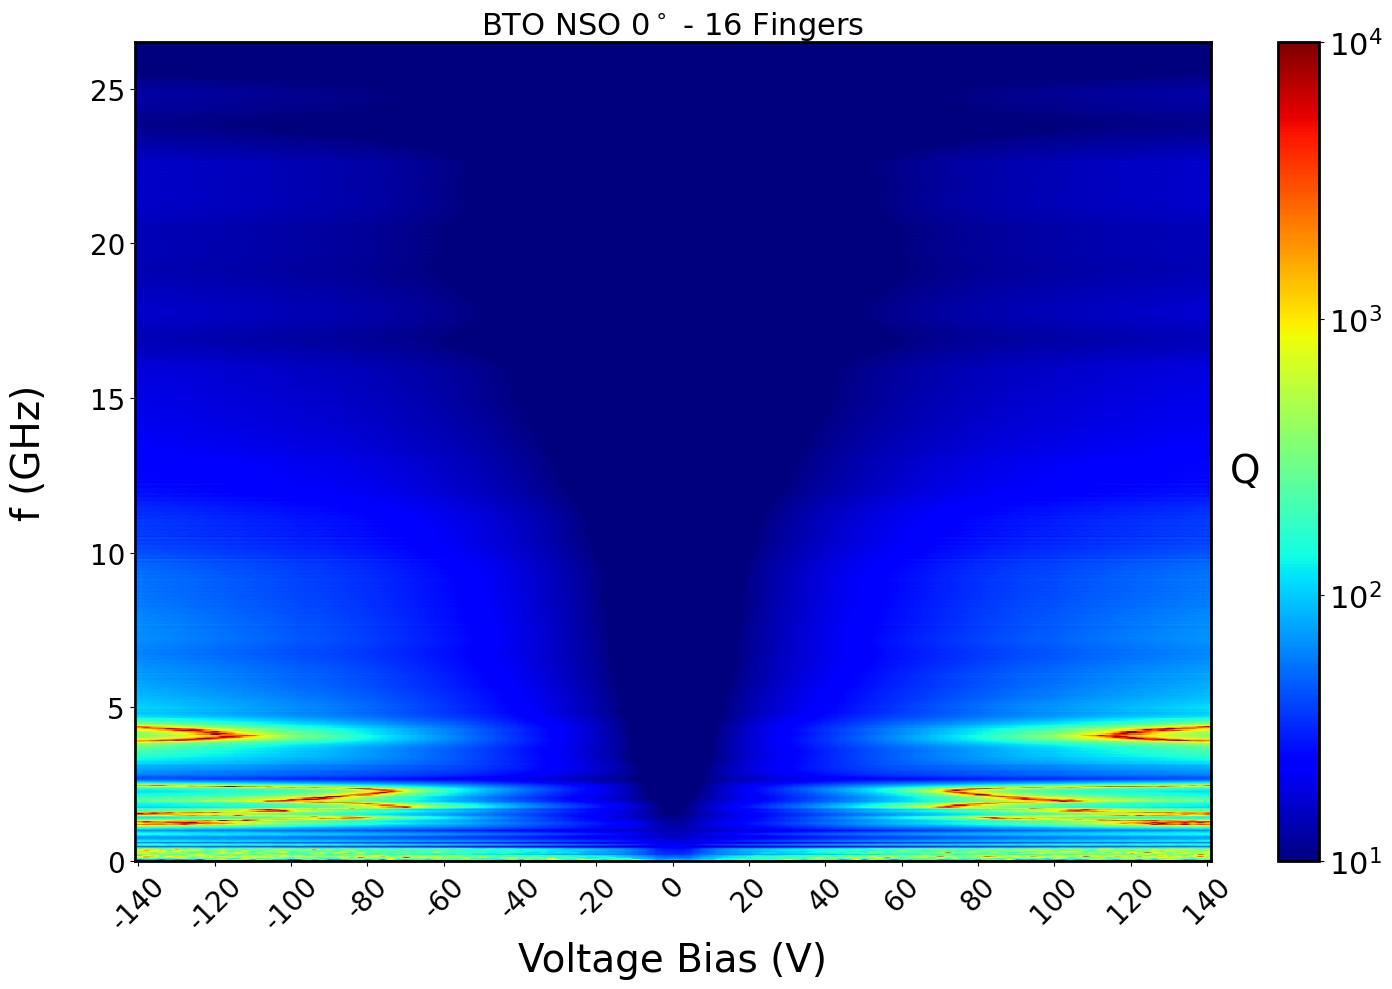

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Filter data for a specific finger count


# Filter the data for the specified finger count
df_filtered = all_data[all_data['Finger Count'] == finger_count]
Q_columns = [col for col in df_filtered.columns if col.startswith('Q_')]
frequency_values = df_filtered['Frequency'].values / 1e9  # Convert to GHz

# Prepare the heatmap data
heatmap_data = df_filtered[Q_columns].copy()
heatmap_data['Frequency'] = frequency_values
heatmap_data = heatmap_data.set_index('Frequency')
voltage_labels = [col.split('_')[1] for col in Q_columns]
heatmap_data.columns = voltage_labels

# Apply logarithmic scale to the data
heatmap_data_log = np.log1p(heatmap_data)

# Determine the global min and max Q values for consistent scaling
vmin = np.log1p(1e1)  # Set the minimum value for the colormap
vmax = np.log1p(1e4)  # Set the maximum value for the colormap

# Create the heatmap figure
plt.figure(figsize=(15, 10))
ax = plt.gca()

# Plot the heatmap using imshow
cax = ax.imshow(
    heatmap_data_log.values,
    aspect='auto',
    cmap='jet',
    vmin=vmin,
    vmax=vmax,
    origin='lower'  # Ensure lower frequencies are at the bottom
)

# Add color bar with appropriate labels
cbar = plt.colorbar(cax, ax=ax)
cbar.set_ticks([vmin, np.log1p(1e2), np.log1p(1e3), vmax])
cbar.set_ticklabels([r'$10^1$', r'$10^2$', r'$10^3$', r'$10^4$'])
cbar.set_label('Q', fontsize=28, rotation = 0, labelpad = -99)
cbar.ax.tick_params(labelsize=22)

# Set title and axis labels
ax.set_title(f'BTO NSO $0^\circ$ - {finger_count} Fingers', fontsize=22)
ax.set_xlabel('Voltage Bias (V)', fontsize=28)
ax.set_ylabel('f (GHz)', fontsize=28, labelpad=30)

# Set the x-axis labels to show round numbers
voltage_ticks = np.arange(-140, 141, 20)
voltage_tick_indices = np.linspace(0, len(voltage_labels) - 1, len(voltage_ticks))

ax.set_xticks(voltage_tick_indices)
ax.set_xticklabels(voltage_ticks, fontsize=20, rotation=45)

# Generate y-ticks at 5 GHz intervals up to 26.5 GHz
yticks = np.arange(0, 26.5 + 1, 5)

# Interpolate y-tick positions to match the data
ytick_indices = np.interp(yticks, frequency_values, np.arange(len(frequency_values)))

ax.set_yticks(ytick_indices)
ax.set_yticklabels([f'{ytick:.0f}' for ytick in yticks], fontsize=20)

plt.tight_layout()
plt.show()


In [35]:
def fitting_function(V, Cmax, V_half, Cf):
    return (Cmax - Cf) / (2 * np.cosh(2/3 * np.arcsinh(2 * V / V_half))-1) + Cf


def func_curve_fitting(Cmax,V_half,fitting_function,voltages, capacitance_data):
# Perform curve fitting
    initial_guess = [Cmax, V_half, 1e-14]  # Adjust as needed
    bounds = ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
    #bounds = ([1e-13,-100,0], [5e-12, 100, 5e-14])
    popt, _ = curve_fit(fitting_function, voltages, capacitance_data, p0=initial_guess, bounds=bounds)
    return(popt)

In [36]:

# Initialize a datadict to store fitting parameters (1/3)
data_dicts=[]

# Assuming 'frequencies' is your array of frequencies and 'all_data' your DataFrame
#selected_frequencies = frequencies  # All frequencies of interest
voltages = voltage_range_subset  # Voltage values


# Initialize arrays to store the fitting parameters
Cmax_values = []
V_half_values = []
Cf_values = []


subset = all_data[all_data['Finger Count'] == finger_count]
subset = subset.reset_index(drop=True)  #without this, the indexing isn't right for 
##the subset data frame, and when you try later to slice it it won't work...


for i, freq in enumerate(selected_frequencies):
#for i, freq in enumerate(frequencies):
    frequency_index = np.abs(frequencies - freq).argmin()
    capacitance_data = [subset.at[frequency_index, f'C_{v:+d}V'] for v in voltages] 
    
    #slices the dataframe along 
    ## just one frequency to get Capacitance values as a
    ###function of voltage for that frequency only, puts it into a new list capacitance_data

    # Find Cmax and the corresponding V_half directly from the data
    Cmax = np.max(capacitance_data)
    Cmin = np.min(capacitance_data) # or 0
    C_half = Cmin + (Cmax - Cmin) / 2
    V_half = voltages[np.argmin(np.abs(capacitance_data - C_half))]

    # Perform curve fitting
    popt = func_curve_fitting(Cmax,V_half,fitting_function,voltages, capacitance_data)
    
    # Store the fitting parameters
    Cmax_values.append(popt[0])  #see fitting function, this is storing optim. value of cmax
    V_half_values.append(popt[1]) #see fitting function, this is storing optim. value of vhalf
    Cf_values.append(popt[2]) #see fitting function, this is storing optim. value of fringing cap
    
    ##### this is the new part, adding the fitting parameters to the data 
    ### dictionaries that wind up in the dataframe
    ## After fitting, store the parameters in the datadicts (2/3)   
    data_dicts.append({
        'Frequency': freq,
        'Cmax_fitted': popt[0],
        'V_half': popt[1],
        'Cf': popt[2],
        #'Cmax_measd': ,
        'Cmin':Cmin
    })
    
    # Generate data for the fitted curve
    #V_fit = np.linspace(min(voltages), max(voltages), 1000)
    #C_fit = fitting_function(V_fit, *popt)

fitting_params_df_0_degrees_12_fingers = pd.DataFrame(data_dicts)
fitting_params_df_0_degrees_12_fingers['C_Max_measd']=subset[f'C_+0V'] #drags the measured values of the V=0 capacit along 

# Calculate tunability as the ratio of Cmax_measd to Cmin for each row (frequency)
fitting_params_df_0_degrees_12_fingers['Tunability'] = fitting_params_df_0_degrees_12_fingers['C_Max_measd'] / fitting_params_df_0_degrees_12_fingers['Cmin']

# Add 'Angle' and 'Number of Fingers' columns to df_0_degrees
fitting_params_df_0_degrees_12_fingers['Angle'] = 0  # Assuming all measurements in this DataFrame are at 0 degrees
fitting_params_df_0_degrees_12_fingers['Number of Fingers'] = finger_count  # Assuming all measurements in this DataFrame are for 6

    

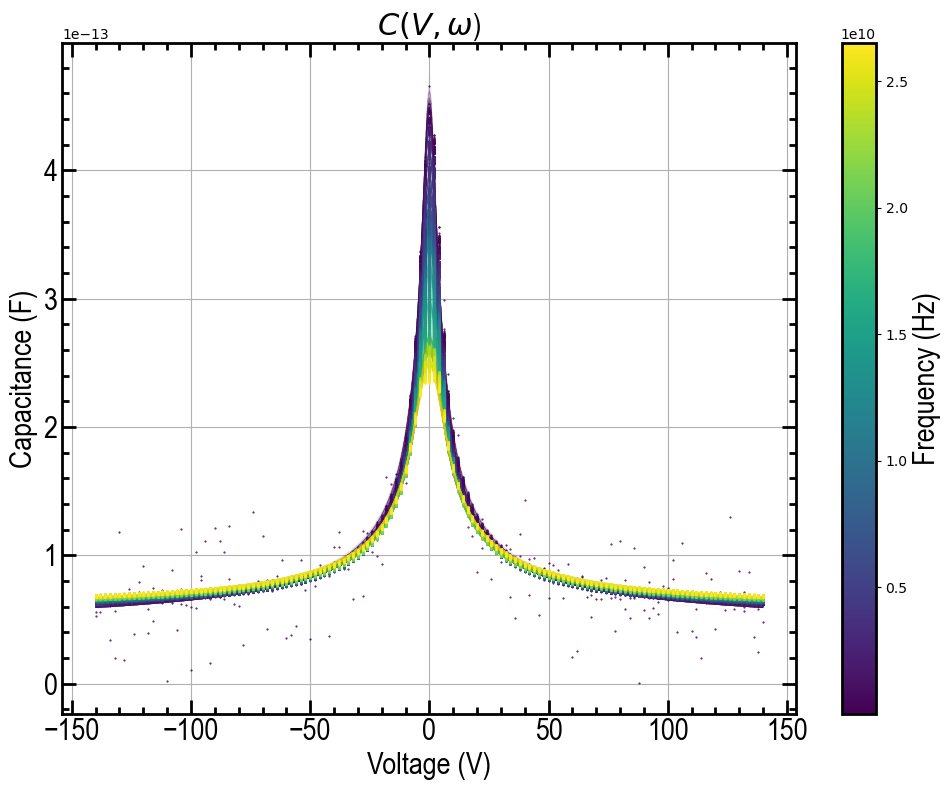

In [38]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import numpy as np
from scipy.optimize import curve_fit




# Create a color map and a normalize object based on the frequency range
norm = colors.Normalize(vmin=min(selected_frequencies), vmax=max(selected_frequencies))
cmap = cm.viridis

# Set up the plot
plt.figure()#figsize=(10, 6))
for freq in selected_frequencies:
    frequency_index = np.abs(frequencies - freq).argmin()
    capacitance_data = [all_data.at[frequency_index, f'C_{v:+d}V'] for v in voltages]

    # Find Cmax and V_half
    Cmax = np.max(capacitance_data)
    Cmin = np.min(capacitance_data)#0
    C_half = Cmin + (Cmax - Cmin) / 2
    V_half = voltages[np.argmin(np.abs(capacitance_data - C_half))]

    # Perform curve fitting
    initial_guess = [Cmax, V_half, 1e-14]
    bounds = ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
    popt, _ = curve_fit(fitting_function, voltages, capacitance_data, p0=initial_guess, bounds=bounds)

    # Generate data for the fitted curve
    V_fit = np.linspace(min(voltages), max(voltages), 1000)
    C_fit = fitting_function(V_fit, *popt)

    # Plot the data and the fitted curve
    plt.plot(V_fit, C_fit,'--',linewidth=.025, color=cmap(norm(freq)))
    #plt.semilogy(V_fit, C_fit, color=cmap(norm(freq)))
    plt.plot(voltages, capacitance_data,marker='.',markersize=1,linestyle='', color=cmap(norm(freq)))

# Add a colorbar to the plot
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Frequency (Hz)',fontdict=font)

##########################################################################################
##########################################################################################
##########################################################################################

plt.rcParams["figure.figsize"]=[10,8]
plt.rcParams["figure.autolayout"]=False
plt.rcParams['axes.linewidth']=2
font = {'family': 'Arial Narrow',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

plt.minorticks_on()

# Customizing x-axis tick parameters
plt.gca().xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
plt.gca().xaxis.set_tick_params(which='minor', size=5, width=2, direction='in', top='on')

# Customizing y-axis tick parameters
plt.gca().yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
plt.gca().yaxis.set_tick_params(which='minor', size=5, width=2, direction='in', right='off')

plt.xticks(fontsize=font['size'], fontname=font['family'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], color=font['color'])


##########################################################################################
##########################################################################################
##########################################################################################


plt.title('$C(V,\omega$)',fontdict=font)
plt.xlabel('Voltage (V)',fontdict=font)
plt.ylabel('Capacitance (F)',fontdict=font)
plt.grid(True)
plt.tight_layout()
plt.show()

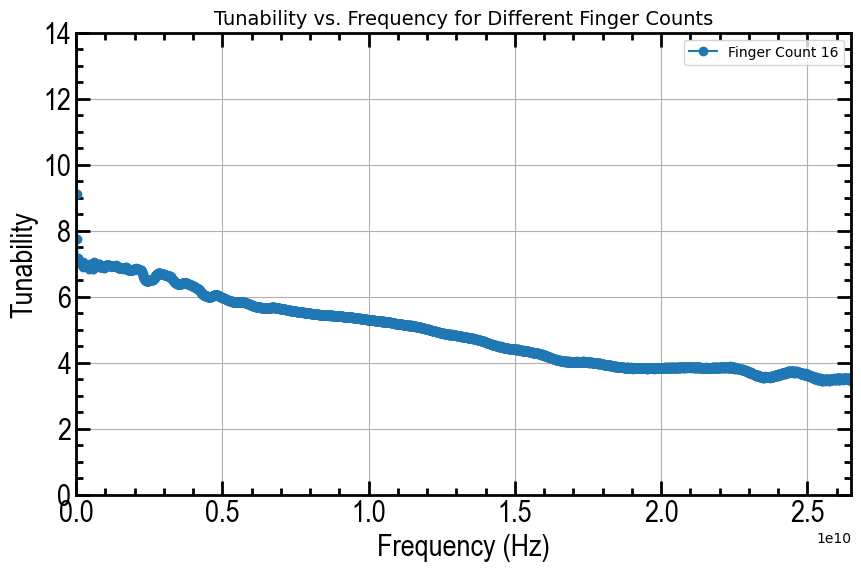

In [39]:
# Create a figure and an axes object
fig, ax = plt.subplots(figsize=(10, 6))


plt.rcParams["figure.figsize"]=[6.5,7]
plt.rcParams["figure.autolayout"]=False
plt.rcParams['axes.linewidth']=2
font = {'family': 'Arial Narrow',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

finger_counts=[12]
# Define a colormap or use distinct markers if preferred
colors = plt.cm.viridis(np.linspace(0, 1, len(finger_counts)))




subset = fitting_params_df_0_degrees_12_fingers[fitting_params_df_0_degrees_12_fingers['Number of Fingers'] == finger_count]

# Plotting
ax.plot(subset['Frequency'], subset['Tunability'], label=f'Finger Count {finger_count}', marker='o')

# Adding labels and title
ax.set_xlabel('Frequency (Hz)', fontdict=font)
ax.set_ylabel('Tunability',fontdict=font)
ax.set_title('Tunability vs. Frequency for Different Finger Counts', fontsize=14)
plt.xlim(0,np.max(selected_frequencies))
plt.ylim(0,14)

# Adding a legend to differentiate the lines
ax.legend()

plt.minorticks_on()

# Customizing x-axis tick parameters
plt.gca().xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
plt.gca().xaxis.set_tick_params(which='minor', size=5, width=2, direction='in', top='on')

# Customizing y-axis tick parameters
plt.xticks(fontsize=font['size'], fontname=font['family'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], color=font['color'])


plt.gca().yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
plt.gca().yaxis.set_tick_params(which='minor', size=5, width=2, direction='in', right='off')
plt.legend()

plt.grid(True)
###########################################################################################

# Show the plot
plt.show()


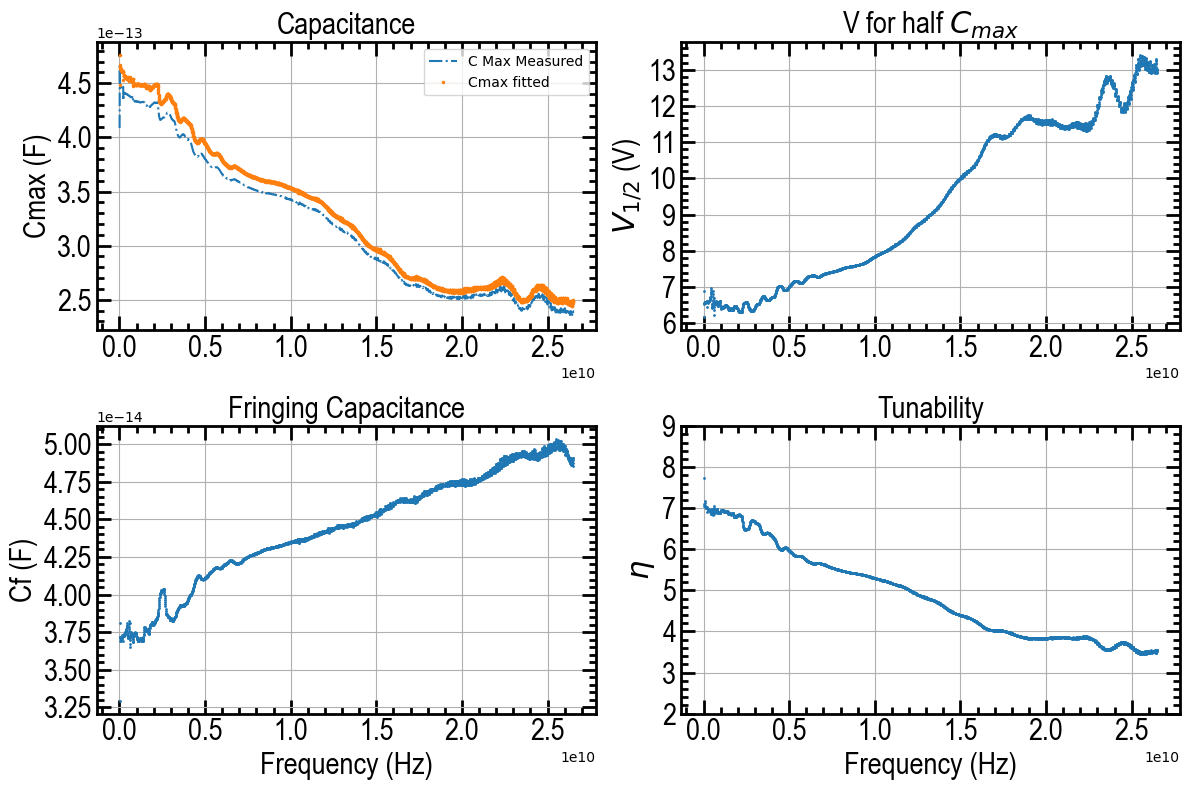

In [42]:

# Plotting the parameters as a function of frequency
plt.figure(figsize=(12, 8))


# Plot Cmax vs Frequency
plt.subplot(2, 2, 1)
plt.plot(fitting_params_df_0_degrees_12_fingers['Frequency'], fitting_params_df_0_degrees_12_fingers['C_Max_measd'], '-.',label='C Max Measured')
plt.plot(fitting_params_df_0_degrees_12_fingers['Frequency'], fitting_params_df_0_degrees_12_fingers['Cmax_fitted'], label=f'Cmax fitted', marker='.', linestyle='-.',markersize=3,linewidth=.05,)
plt.ylabel('Cmax (F)',fontdict=font)
plt.title('Capacitance',fontdict=font)
plt.legend()

###########################################################################################
###########################################################################################
###########################################################################################
plt.minorticks_on()

# Customizing x-axis tick parameters
plt.gca().xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
plt.gca().xaxis.set_tick_params(which='minor', size=5, width=2, direction='in', top='on')

# Customizing y-axis tick parameters
plt.xticks(fontsize=font['size'], fontname=font['family'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], color=font['color'])


plt.gca().yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
plt.gca().yaxis.set_tick_params(which='minor', size=5, width=2, direction='in', right='off')

plt.grid(True)
###########################################################################################
###########################################################################################
###########################################################################################


# Plot V_half vs Frequency
plt.subplot(2, 2, 2)
plt.plot(fitting_params_df_0_degrees_12_fingers['Frequency'], np.abs(fitting_params_df_0_degrees_12_fingers['V_half']), 'o',markersize=1)
plt.ylabel('$V_{1/2}$ (V)',fontdict=font)
plt.title('V for half $C_{max}$',fontdict=font)


###########################################################################################
plt.minorticks_on()

# Customizing x-axis tick parameters
plt.gca().xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
plt.gca().xaxis.set_tick_params(which='minor', size=5, width=2, direction='in', top='on')

# Customizing y-axis tick parameters
plt.xticks(fontsize=font['size'], fontname=font['family'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], color=font['color'])


plt.gca().yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
plt.gca().yaxis.set_tick_params(which='minor', size=5, width=2, direction='in', right='off')

plt.grid(True)
###########################################################################################

# Plot Cf vs Frequency
plt.subplot(2, 2, 3)
plt.plot(fitting_params_df_0_degrees_12_fingers['Frequency'], fitting_params_df_0_degrees_12_fingers['Cf'], 'o',markersize=1)
plt.ylabel('Cf (F)',fontdict=font)
plt.title('Fringing Capacitance',fontdict=font)
plt.xlabel('Frequency (Hz)',fontdict=font)
#plt.axvline(x=1e9)


###########################################################################################
plt.minorticks_on()

# Customizing x-axis tick parameters
plt.gca().xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
plt.gca().xaxis.set_tick_params(which='minor', size=5, width=2, direction='in', top='on')

# Customizing y-axis tick parameters
plt.xticks(fontsize=font['size'], fontname=font['family'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], color=font['color'])


plt.gca().yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
plt.gca().yaxis.set_tick_params(which='minor', size=5, width=2, direction='in', right='off')

plt.grid(True)
###########################################################################################

# Plot Cf vs Frequency
plt.subplot(2, 2, 4)
plt.plot(fitting_params_df_0_degrees_12_fingers['Frequency'], fitting_params_df_0_degrees_12_fingers['Tunability'], 'o',markersize=1)
plt.ylabel('$\eta$',fontdict=font)
plt.title('Tunability',fontdict=font)
plt.ylim(2,9)
plt.xlabel('Frequency (Hz)',fontdict=font)
#plt.axvline(x=1e9)

###########################################################################################

###########################################################################################
plt.minorticks_on()

# Customizing x-axis tick parameters
plt.gca().xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
plt.gca().xaxis.set_tick_params(which='minor', size=5, width=2, direction='in', top='on')

# Customizing y-axis tick parameters
plt.xticks(fontsize=font['size'], fontname=font['family'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], color=font['color'])


plt.gca().yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
plt.gca().yaxis.set_tick_params(which='minor', size=5, width=2, direction='in', right='off')

plt.grid(True)
###########################################################################################



plt.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


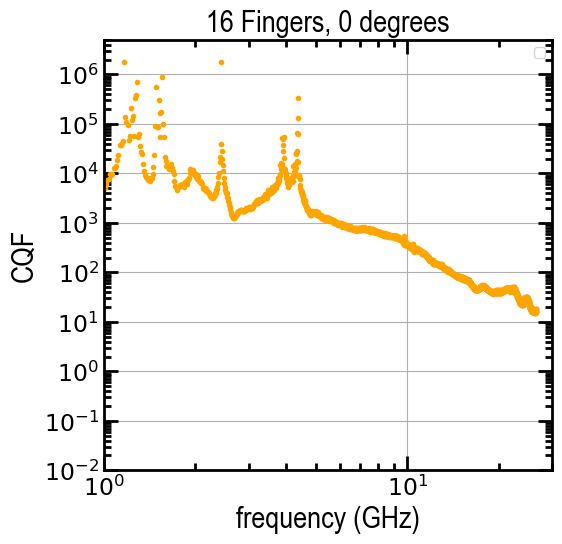

In [49]:
import matplotlib.pyplot as plt

plt.rcParams["figure.autolayout"] = False
plt.rcParams['axes.linewidth'] = 2
font = {'family': 'Arial Narrow', 'color': 'black', 'weight': 'normal', 'size': 22}


# Define the finger counts you want to plot for
finger_counts = [16]

# Create a figure with a 2x3 grid of subplots
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Flatten the array of axes for easy iteration using a flat index
axes = axs.flatten()

# Set common y-axis limits after checking the range you need
# Example: Assume after reviewing all data, you decide on these limits
y_min, y_max = 1e-2, 5e6
x_min, x_max = 1, 30

# Loop through each finger count and corresponding subplot axis
for count, ax in zip(finger_counts, axes):
    # Filter the data for the current finger count
    
    tunability_data = fitting_params_df_0_degrees_12_fingers[fitting_params_df_0_degrees_12_fingers['Number of Fingers'] == count]['Tunability']
    q_data = all_data[all_data['Finger Count'] == count]

    freq_data = fitting_params_df_0_degrees_12_fingers[fitting_params_df_0_degrees_12_fingers['Number of Fingers'] == count]['Frequency']/1e9
    #cqf = tunability_data * q_data
    cqf = q_data['Q_+0V']*q_data['Q_+140V']*(tunability_data-2+1/tunability_data)
    # compare with John C's calculation of the same 
    #CQF = ((abs(((Y12i(:,VoltMid+1)-Y12i(:,N)).^2)./(Y12r(:,VoltMid+1).*Y12r(:,N)))))+((abs(((Y12i(:,VoltMid+1)-Y12i(:,1)).^2)./(Y12r(:,VoltMid+1).*Y12r(:,1)))));

    
    # Plotting different voltage conditions
    ax.loglog(freq_data, cqf, '.', color='orange')

    ax.set_title(f'{count} Fingers, 0 degrees',fontdict=font)
    ax.set_xlabel('frequency (GHz)',fontdict=font)
    ax.set_ylabel('CQF',fontdict=font)
    ax.legend()

    # Set common y-axis limits for all plots
    ax.set_ylim(y_min, y_max)
    ax.set_xlim(x_min, x_max)
    ########    ########    ########    ########    ########    ########    ########
        ########    ########    ########    ########    ########    ########    ########

    # Customize x-axis and y-axis tick parameters specifically for each ax
    ax.xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
    ax.xaxis.set_tick_params(which='minor', size=5, width=2, direction='in', top='on')
    ax.yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
    ax.yaxis.set_tick_params(which='minor', size=5, width=2, direction='in', right='off')

    # Setting font sizes for tick labels
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.tick_params(axis='both', which='minor', labelsize=17)

    ax.minorticks_on()
    ax.grid(True)

     ########    ########    ########    ########    ########    ########    ########
        ########    ########    ########    ########    ########    ########    ########

# Hide unused axes if the number of finger counts is less than the number of subplots
for unused_ax in axes[len(finger_counts):]:
    unused_ax.set_visible(False)

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()
